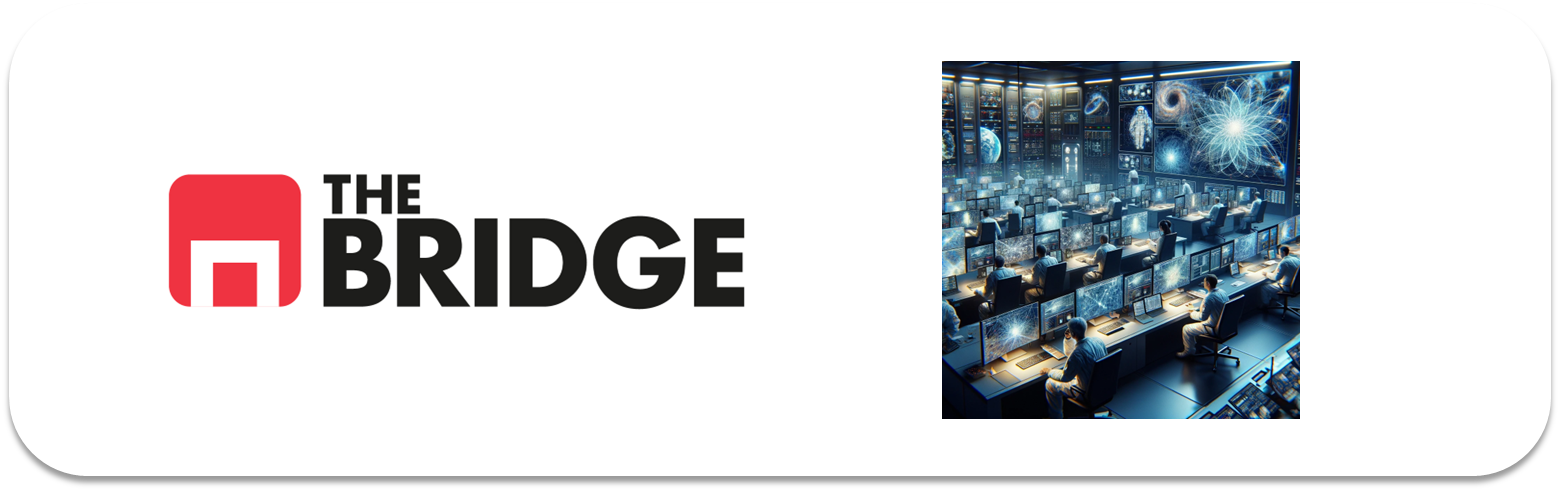

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from PIL import Image


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



### **Creamos datasets X, y de train y test**

In [3]:
# Ruta base de los datos
DATA_PATH = "data"
IMG_SIZE = 32  # Resolución objetivo: 32x32 píxeles

def cargar_imagenes(directorios, img_size=IMG_SIZE):
    """
    Lee imágenes de una lista de directorios, las redimensiona a img_size x img_size
    y extrae la etiqueta del nombre del archivo (cat=0, dog=1).
    """
    imagenes = []
    etiquetas = []
    nombres = []  # Guardamos los nombres para el ejercicio 5
    
    for directorio in directorios:
        ruta = os.path.join(DATA_PATH, directorio)
        archivos = os.listdir(ruta)
        
        for archivo in archivos:
            if not archivo.endswith('.jpg'):
                continue
            
            filepath = os.path.join(ruta, archivo)
            
            # Leer imagen con PIL y redimensionar
            try:
                img = Image.open(filepath).convert('RGB')
                img = img.resize((img_size, img_size))
                img_array = np.array(img)
                imagenes.append(img_array)
                
                # Extraer etiqueta del nombre: cat.XXXX.jpg -> 0, dog.XXXX.jpg -> 1
                etiqueta = 0 if archivo.startswith('cat') else 1
                etiquetas.append(etiqueta)
                nombres.append(archivo)
                
            except Exception as e:
                print(f"Error leyendo {filepath}: {e}")
    
    return np.array(imagenes), np.array(etiquetas), nombres

In [4]:
# Cargar datos de TRAIN (4 carpetas)

train_dirs = ["github_train_0", "github_train_1", "github_train_2", "github_train_3"]
X_train_full, y_train_full, nombres_train = cargar_imagenes(train_dirs)

In [5]:
# Cargar datos de TEST (1 carpeta)

test_dirs = ["github_test"]
X_test, y_test, nombres_test = cargar_imagenes(test_dirs)

In [6]:
# Escalamos TRAIN dividiendo por 255 para tener todos los valores entre 0 y 1

X_train_norm = X_train_full / 255
X_test_norm = X_test / 255

In [7]:
X_train_norm[0].shape # Este sería el tamaño de la imagen (32x32) y 3 canales de color (RGB)

(32, 32, 3)

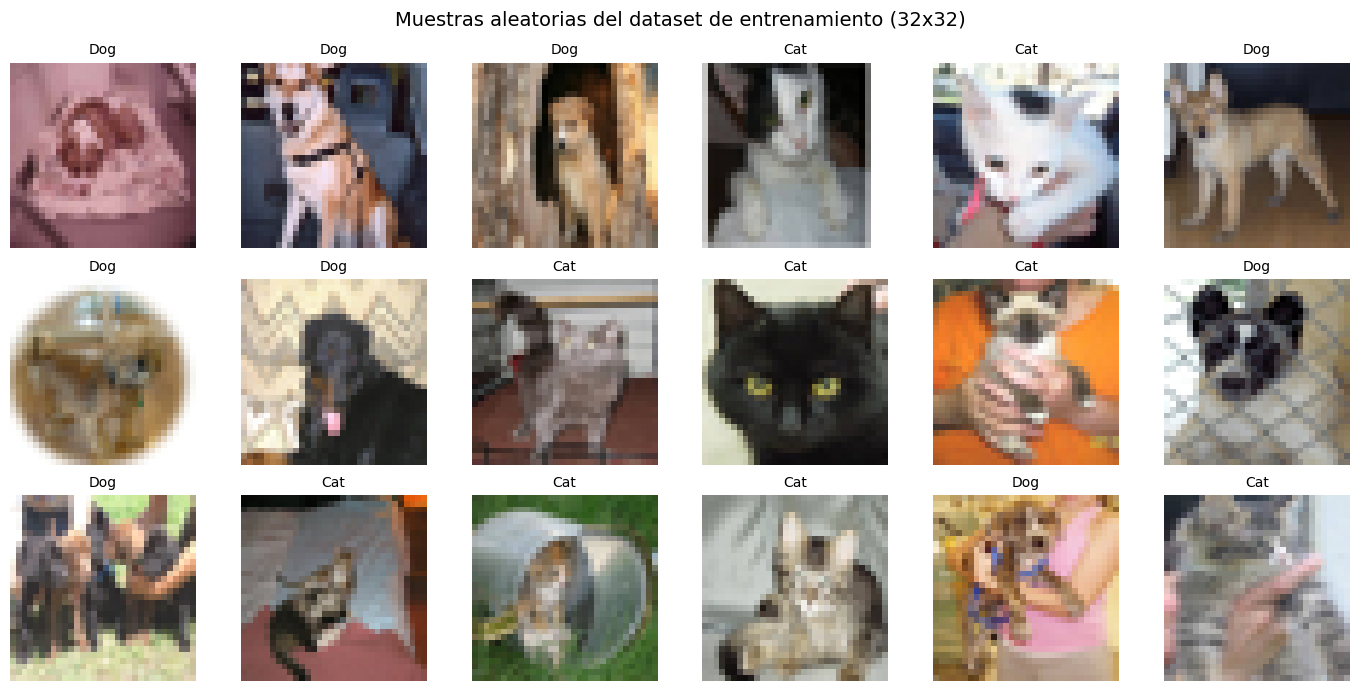

In [8]:
# Visualizar muestras aleatorias del dataset de TRAIN

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
clases = {0: "Cat", 1: "Dog"}

for i, ax in enumerate(axes.flatten()):
    idx = np.random.randint(0, len(X_train_full))
    ax.imshow(X_train_full[idx])
    ax.set_title(clases[y_train_full[idx]], fontsize=10)
    ax.axis('off')

plt.suptitle("Muestras aleatorias del dataset de entrenamiento (32x32)", fontsize=14)
plt.tight_layout()
plt.show()

### **MiniEDA y construcción del modelo**

In [9]:
import bootcampviztools as bcvt 

# Crear un DF solo para visualizar la distribución de clases     
            
df_train = pd.DataFrame({'clase': y_train_full})                                       
df_train['clase'] = df_train['clase'].map({0: 'Cat', 1: 'Dog'})

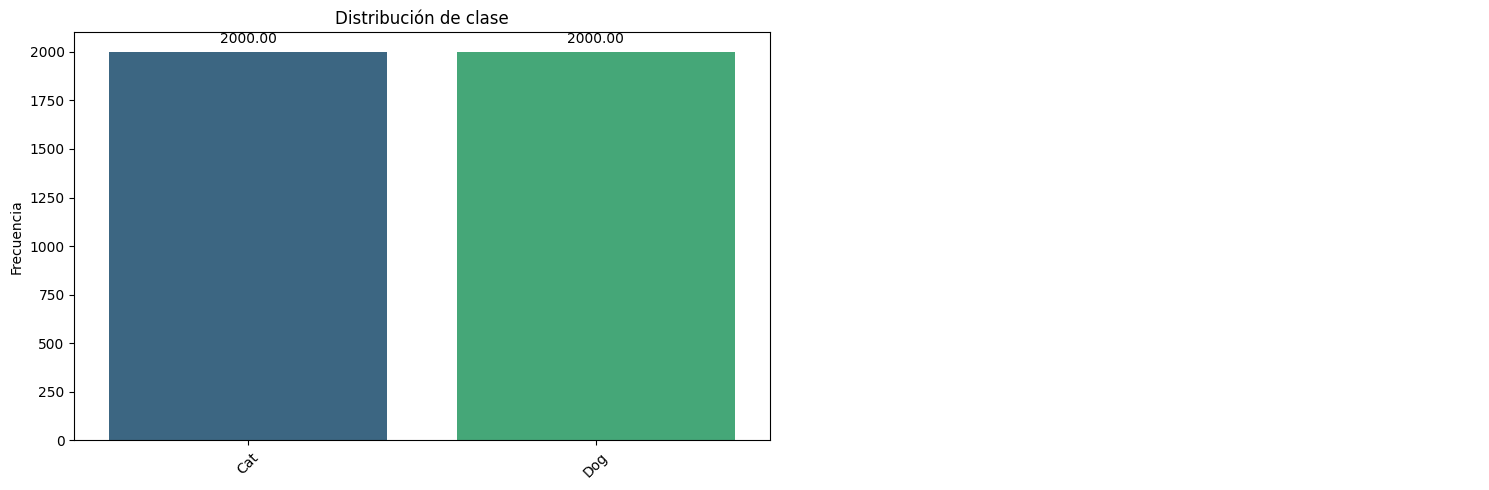

In [10]:
bcvt.pinta_distribucion_categoricas(df_train, ['clase'], mostrar_valores=True) 

In [11]:
# Dividimos train en train/validation (80/20) para monitorizar el entrenamiento

X_train, X_val, y_train, y_val = train_test_split(
    X_train_norm, 
    y_train_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_full
    )

In [12]:
print(X_train.shape)
print(y_train.shape)

(3200, 32, 32, 3)
(3200,)


In [13]:
# Construimos el modelo formado por todas las capas: 
# Dos juegos de capas convolucionales + pooling con función de activación 'Relu' 
# Dos capas densas finales con una de Dropout intermedia
# La capa de salida aplica una función de activación 'Sigmoide'


model = Sequential([

    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Salida binaria: cat(0) vs dog(1)
])

In [14]:
# Compilamos con binary crossentropy (clasificación binaria)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,321 (2.08 MB)

 Trainable params: 544,129 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

### **Entrenamiento del modelo con EarlyStopping**

In [19]:
# Configuramos un earlystopping que pare entrenamiento si no mejora la pérdida de validación durante 10 épocas

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [20]:
# Entrenamos el modelo

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6581 - loss: 0.6257 - val_accuracy: 0.5025 - val_loss: 1.1209
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6834 - loss: 0.5782 - val_accuracy: 0.5650 - val_loss: 0.8598
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7337 - loss: 0.5256 - val_accuracy: 0.5950 - val_loss: 0.9486
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7531 - loss: 0.4902 - val_accuracy: 0.5925 - val_loss: 1.1365
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7825 - loss: 0.4492 - val_accuracy: 0.6288 - val_loss: 0.9895
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8059 - loss: 0.4179 - val_accuracy: 0.6275 - val_loss: 1.1090
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8291 - loss: 0.3759 - val_accuracy: 0.6662 - val_loss: 1.0711
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8441 - loss: 0.3359 - val_accuracy: 0.6538 - v

### **Evaluación del modelo**

In [21]:
# Predicciones: probabilidades y clases

y_pred_proba = model.predict(X_test_norm).flatten()  # Probabilidad de ser dog (clase 1)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Classification Report

print(classification_report(y_test, y_pred, target_names=["Cat (0)", "Dog (1)"]))                                                                                                                 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

     Cat (0)       0.70      0.79      0.74       500
     Dog (1)       0.76      0.66      0.70       500

    accuracy                           0.72      1000
   macro avg       0.73      0.72      0.72      1000
weighted avg       0.73      0.72      0.72      1000



NameError: name 'test_acc' is not defined

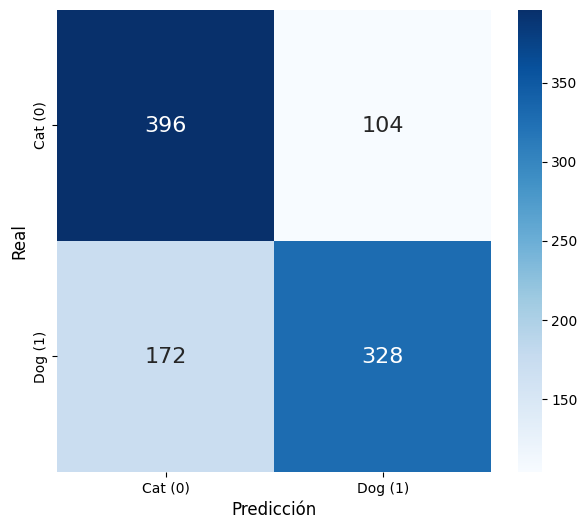

In [22]:
# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Cat (0)", "Dog (1)"],
            yticklabels=["Cat (0)", "Dog (1)"],
            ax=ax, annot_kws={"size": 16})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión (Accuracy: {test_acc:.2%})', fontsize=14)
plt.tight_layout()
plt.show()